# Proyecto Integrador (TC5035)
# Identificación de Gestos en el Lenguaje de Manos Mexicano
# Avance 4. Modelos alternativos
---
## EQUIPO 51
- CARLOS MIGUEL ARVIZU DURÁN - A01410682
- YOHANNA CEBALLOS SALOMÓN - A01795115
- RUBÉN DÍAZ GARCÍA - A01371849

## Profesores
- PROFESOR ASESOR: DR. RAÚL VALENTE RAMÍREZ VELARDE
- PROFESORA TITULAR: DRA. GRETTEL BARCELÓ ALONSO
- PROFESOR TITULAR: DR. LUIS EDUARDO FALCÓN MORALES
- PROFESORA ASISTENTE: MTRA. VERÓNICA SANDRA GUZMÁN DE VALLE

---

# Modelo 2 GRU (Gated Recurrent Unit)

**GRU (Gated Recurrent Unit)**

   Este modelo se selecciona por su capacidad para procesar secuencias temporales de manera eficiente, similar a las LSTM, pero con menor complejidad computacional.  
   Las GRU aprenden dependencias a largo plazo entre los fotogramas de cada seña, siendo ideales cuando los datos corresponden a movimientos continuos de las manos.  
   Se espera que capture la dinámica temporal entre los landmarks y mejore la generalización en comparación con modelos puramente densos.

## Librerías

In [1]:
import os
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score

## Carga de Datos

In [2]:
# CONFIGURACIÓN: se debe ajustar a la carpeta desde donde se corre el programa
notebook_dir = Path.cwd() 
current_script_dir = notebook_dir#.parent
parent_dir = current_script_dir
PROCESSED_DATA_DIR = parent_dir / "processed_data_pipeline"
data_dir = parent_dir / "data"
VIDEOS_DIR =  data_dir / "videos"

print(f"\nPaths: \nPROCESSED DATA DIRECTORY: {PROCESSED_DATA_DIR} \nVIDEOS DIRECTORY: {VIDEOS_DIR}")


Paths: 
PROCESSED DATA DIRECTORY: /Users/raven/Documents/Code/MNA/lsm/TC5035-PI-E51/Avance4/processed_data_pipeline 
VIDEOS DIRECTORY: /Users/raven/Documents/Code/MNA/lsm/TC5035-PI-E51/Avance4/data/videos


In [3]:
# --- Cargar los Datos Preprocesados ---
print("--- Cargando datos preprocesados ---")
X_train = np.load(os.path.join(PROCESSED_DATA_DIR, "X_train.npy"))
X_test = np.load(os.path.join(PROCESSED_DATA_DIR, "X_test.npy"))
y_train_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_train.csv"))
y_test_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "y_test.csv"))
y_train_labels = y_train_df['class'].values
y_test_labels = y_test_df['class'].values

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}\n")

# --- Codificar las Etiquetas ---
print("\n--- Codificando las etiquetas ---")
label_encoder = LabelEncoder()
all_labels = np.concatenate([y_train_labels, y_test_labels])
label_encoder.fit(all_labels)
y_train_encoded = label_encoder.transform(y_train_labels)
y_test_encoded = label_encoder.transform(y_test_labels)
num_classes = len(label_encoder.classes_)

# Dividimos los datos de entrenamiento para crear un conjunto de validación
# Usaremos el 15% de los datos de entrenamiento para validación
X_train, X_val, y_train_encoded, y_val_encoded = train_test_split(
    X_train, 
    y_train_encoded, 
    test_size=0.15, # 15% para validación
    random_state=42,
    stratify=y_train_encoded # Mantiene la proporción de clases
)

y_train_categorical = to_categorical(y_train_encoded, num_classes=num_classes)
y_val_categorical = to_categorical(y_val_encoded)
y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)
print(f"Número de clases únicas: {num_classes}")

--- Cargando datos preprocesados ---
Forma de X_train: (164, 150, 5)
Forma de X_test: (41, 150, 5)


--- Codificando las etiquetas ---
Número de clases únicas: 4


## Modelo 2 GRU (Gated Recurrent Unit)

In [4]:
# --- Construir el Modelo GRU ---
print("\n--- Construyendo la arquitectura del modelo GRU ---")
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, return_sequences=True),
    Dropout(0.5),
    GRU(64, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# --- Compilar el Modelo ---
print("\n--- Compilando el modelo ---")
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])
model.summary()


--- Construyendo la arquitectura del modelo GRU ---

--- Compilando el modelo ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 150, 64)        │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,012 (168.02 KB)

 Trainable params: 43,012 (168.02 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [5]:
# --- Entrenamiento del Modelo ---
print("\n--- Entrenando el modelo ---")
history = model.fit(
    X_train, 
    y_train_categorical,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val_categorical),
    verbose=1
)


--- Entrenando el modelo ---
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.4676 - loss: 1.2380 - val_accuracy: 0.6800 - val_loss: 1.0703
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6906 - loss: 1.0293 - val_accuracy: 0.6800 - val_loss: 0.9212
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7194 - loss: 0.9070 - val_accuracy: 0.6800 - val_loss: 0.8358
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7050 - loss: 0.8273 - val_accuracy: 0.7200 - val_loss: 0.7816
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7482 - loss: 0.7571 - val_accuracy: 0.7200 - val_loss: 0.7324
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7842 - loss: 0.6789 - val_accuracy: 0.7200 - val_loss: 0.7060
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.7842 - loss: 0.6795 - val_accuracy: 0.7200 - val_loss: 0.6786
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7770 - loss: 0.6315 - val_accura

## Resultados

In [6]:
# --- Evaluar y Visualizar los Resultados ---
print("\n--- Evaluando el modelo con métricas detalladas ---")

# Realizar predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
# Convertir las probabilidades a etiquetas de clase predichas (la de mayor probabilidad)
y_pred_encoded = np.argmax(y_pred_probabilities, axis=1)


--- Evaluando el modelo con métricas detalladas ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [7]:
# Reporte de Clasificación
print("\n--- Reporte de Clasificación ---")
report = classification_report(y_test_encoded, y_pred_encoded, target_names=label_encoder.classes_)
print(report)

# Accuracy (Precisión Global)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"La precisión (accuracy) del modelo es: {accuracy:.2f}")

# Recall
recall = recall_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El recall (weighted) del modelo es: {recall:.2f}")

# F1-score
f1 = f1_score(y_test_encoded, y_pred_encoded, average='weighted')
print(f"El F1-score (weighted) del modelo es: {f1:.2f}")


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

       Abrir       0.91      1.00      0.95        10
      Avión       0.91      1.00      0.95        10
      Borrar       1.00      0.91      0.95        11
          Tu       1.00      0.90      0.95        10

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.96      0.95      0.95        41

La precisión (accuracy) del modelo es: 0.95
El recall (weighted) del modelo es: 0.95
El F1-score (weighted) del modelo es: 0.95



--- Matriz de Confusión  ---


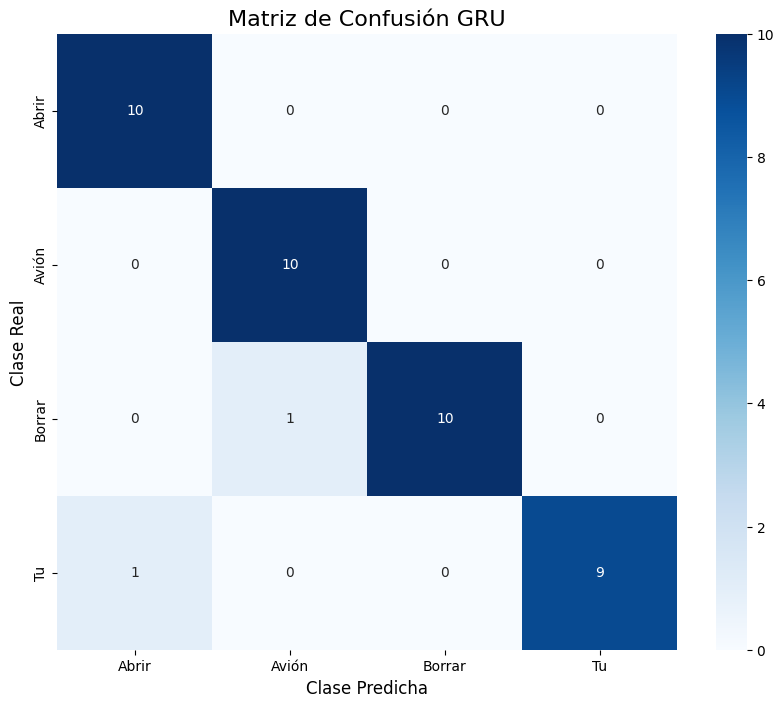

In [8]:
# Matriz de Confusión
print("\n--- Matriz de Confusión  ---")
cm = confusion_matrix(y_test_encoded, y_pred_encoded)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Matriz de Confusión GRU', fontsize=16)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.show()



--- Gráfica de precisión y pérdida durante el entrenamiento ---


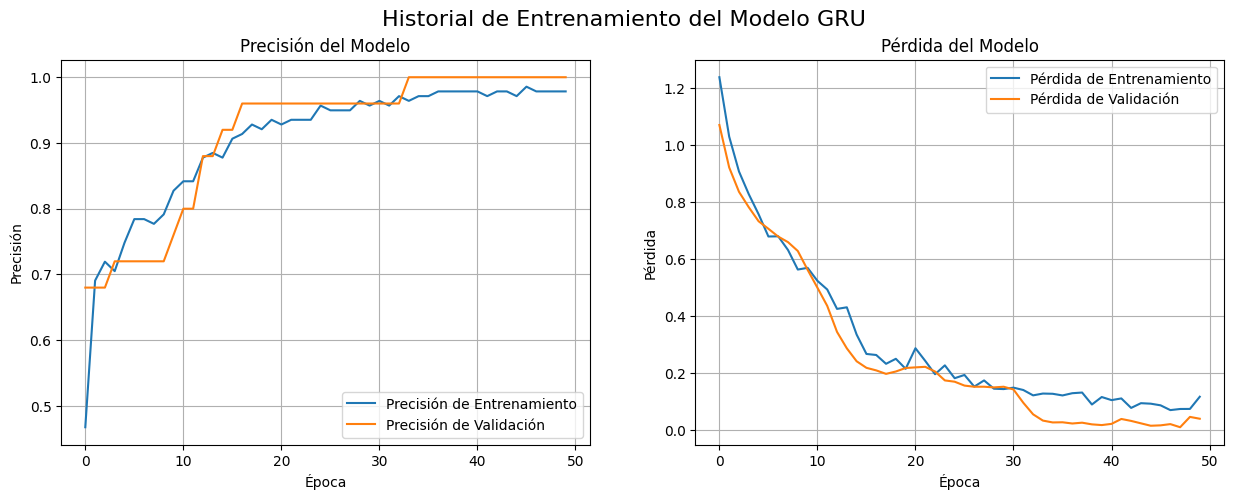


¡Entrenamiento completado!


In [9]:
# Gráfica de precisión y pérdida
print("\n--- Gráfica de precisión y pérdida durante el entrenamiento ---")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica de Precisión
ax1.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
ax1.plot(history.history['val_accuracy'], label='Precisión de Validación')
ax1.set_title('Precisión del Modelo')
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True)

# Gráfica de Pérdida
ax2.plot(history.history['loss'], label='Pérdida de Entrenamiento')
ax2.plot(history.history['val_loss'], label='Pérdida de Validación')
ax2.set_title('Pérdida del Modelo')
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True)

plt.suptitle('Historial de Entrenamiento del Modelo GRU', fontsize=16)
plt.show()

print("\n¡Entrenamiento completado!")